In [1]:
import numpy as np
from model.grid_init import initialize_grid_2d, initialize_grid_3d
from model.parameters import get_default_parameters
from model.population_growth import *
from visualization.plots import plot_3d
from visualization.animation import animate_heatmap_section
from ipywidgets import *
import matplotlib.pyplot as plt

In [2]:
params = get_default_parameters()
time_steps = 3000 # 30 hours

In [3]:
def simulate_perfusion(params, time_steps, distribution=lambda : 0.3 *np.random.rand()):
    density_grid, concentration_grid = initialize_grid_3d(distribution, params.grid_dims)
    drug_source_grid = drug_source(params.source_concentration, params.source_position, params.grid_dims)
    concentration_grid += drug_source_grid * params.dt
    density_grid_history = [density_grid.copy()]
    concentration_grid_history = [concentration_grid.copy()]

    for t in range(time_steps):
        concentration_grid = update_concentration_3d_perfusion(concentration_grid,density_grid, drug_source_grid,
                                                             params.diffusion_rate, params.dt, params.dx, params.decay, params.beta)
        drug_effect_grid = drug_effect(concentration_grid, params.EC50, params.hill_coefficient)
        density_grid = update_density_3d(density_grid, drug_effect_grid, params.r, params.alpha, params.dt, params.dx, params.movement_rate)
        density_grid_history.append(density_grid.copy())
        concentration_grid_history.append(concentration_grid.copy())

    return density_grid_history, concentration_grid_history

In [4]:
def simulate_intervals(params, time_steps, distribution=lambda : 0.3 *np.random.rand()):
    density_grid, concentration_grid = initialize_grid_3d(distribution, params.grid_dims)
    concentration_grid = add_dose(concentration_grid, params.source_concentration, params.source_position)
    density_grid_history = [density_grid.copy()]
    concentration_grid_history = [concentration_grid.copy()]

    for t in range(time_steps):
        if t % round(params.dose_interval / params.dt) == 0:
            concentration_grid = add_dose(concentration_grid, params.source_concentration, params.source_position)
        concentration_grid = update_concentration_3d(concentration_grid, density_grid, params.diffusion_rate,
                                                      params.dt, params.dx, params.decay, params.beta)
        drug_effect_grid = drug_effect(concentration_grid, params.EC50, params.hill_coefficient)
        density_grid = update_density_3d(density_grid, drug_effect_grid, params.r, params.alpha, params.dt, params.dx, params.movement_rate)
        density_grid_history.append(density_grid.copy())
        concentration_grid_history.append(concentration_grid.copy())

    return density_grid_history, concentration_grid_history

In [5]:
density_grid_history_perfusion, concentration_grid_history_perfusion = simulate_perfusion(params, time_steps)
density_grid_history_intervals, concentration_grid_history_intervals = simulate_intervals(params, time_steps)

In [6]:
perfusion_history = {
    'density': density_grid_history_perfusion,
    'concentration': concentration_grid_history_perfusion
}
intervals_history = {
    'density': density_grid_history_intervals,
    'concentration': concentration_grid_history_intervals
}

In [16]:
def plotter(timestep, history):
    plt.figure(figsize=(14, 6))
    plt.subplot(1, 2, 1)
    plt.imshow(history['concentration'][timestep][:, :, params.grid_dims[2]//2], cmap='inferno', vmin=0, vmax=0.5)
    plt.title(f'Concentration at Timestep {timestep}')
    plt.colorbar(label='Concentration (mM)')
    plt.subplot(1, 2, 2)
    plt.imshow(history['density'][timestep][:, :, params.grid_dims[2]//2], cmap='inferno', vmin=0, vmax=1)
    plt.title(f'Density at Timestep {timestep}')
    plt.colorbar(label='Density (normalized)')
    plt.show()

In [17]:
interactive(plotter, timestep= Play(min=0, max=time_steps, value=0, interval=50), 
            history = fixed(perfusion_history))

interactive(children=(Play(value=0, description='timestep', interval=50, max=3000), Output()), _dom_classes=('…

In [ ]:
interactive(plotter, timestep= Play(min=0, max=time_steps, value=0, interval=50), 
            history = fixed(intervals_history))

interactive(children=(Play(value=0, description='timestep', interval=50, max=3000), Output()), _dom_classes=('…

/Users/rayenezanina/Desktop/Project/Tumor simulation/visualization/plots.py:36: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax1.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=colors1, cmap='inferno', vmin=0, vmax=1)
/Users/rayenezanina/Desktop/Project/Tumor simulation/visualization/plots.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  ax2.scatter(X.flatten(), Y.flatten(), Z.flatten(), c=colors2, cmap='inferno', vmin=0, vmax=concentration_grid.max())


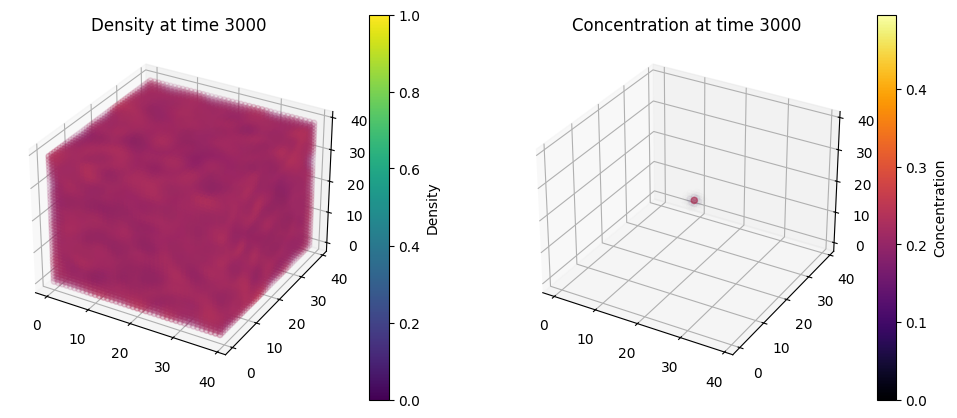

In [10]:
plot_3d(density_grid_history_perfusion[-1], concentration_grid_history_perfusion[-1], time_steps)

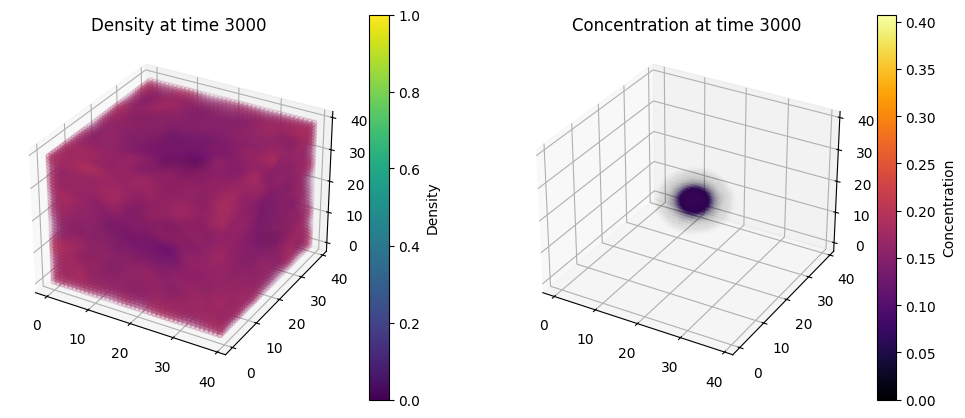

In [11]:
plot_3d(density_grid_history_intervals[-1], concentration_grid_history_intervals[-1], time_steps)

In [12]:
concentration_grid_history_intervals[-1].max()

np.float64(0.40769526828237806)